<a href="https://colab.research.google.com/github/aditijagtap04/Project-/blob/main/customer_churn_model_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
importpdimport numpy as np
import pandapandass as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#rows and cloumn
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
pd.set_option("display.max_column",None)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#droping customer id column
df=df.drop(columns=["customerID"])

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
#unique values
for col in df.columns:
  print(col,df[col].unique())
  print(""*50)

gender ['Female' 'Male']

SeniorCitizen [0 1]

Partner ['Yes' 'No']

Dependents ['No' 'Yes']

tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService ['No' 'Yes']

MultipleLines ['No phone service' 'No' 'Yes']

InternetService ['DSL' 'Fiber optic' 'No']

OnlineSecurity ['No' 'Yes' 'No internet service']

OnlineBackup ['Yes' 'No' 'No internet service']

DeviceProtection ['No' 'Yes' 'No internet service']

TechSupport ['No' 'Yes' 'No internet service']

StreamingTV ['No' 'Yes' 'No internet service']

StreamingMovies ['No' 'Yes' 'No internet service']

Contract ['Month-to-month' 'One year' 'Two year']

PaperlessBilling ['Yes' 'No']

PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]

TotalChar

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
len(df[df["TotalCharges"]==" "])

11

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
#checking distribution of terget column
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
def plot_histogram(df,column_name):

  plt.figure(figsize=(5,3))
  sns.histplot(df[column_name],kde=True)
  plt.title(f"distrbution of {column_name}")

  #calculate mean and median

  clo_mean=df[column_name].mean( )
  clo_median=df[column_name].median()

  plt.axvline(clo_mean,color="red",linestyle="--",label="Mean")
  plt.axvline(clo_median,color="green",linestyle="--",label="Median")

  plt.legend()

  plt.show()

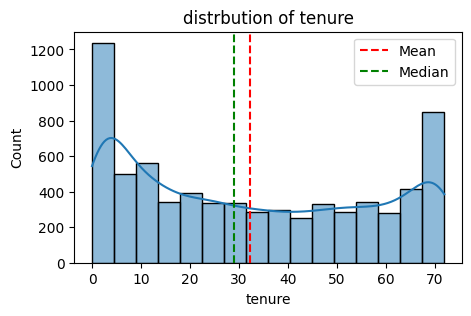

In [ ]:
plot_histogram(df,"tenure")

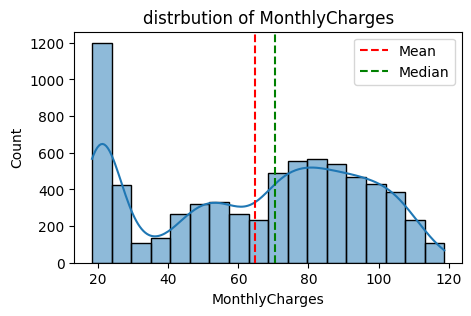

In [ ]:
plot_histogram(df,"MonthlyCharges")

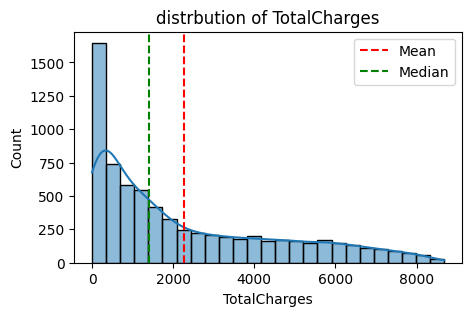

In [ ]:
# Clean the 'TotalCharges' column: replace spaces with '0.0' and convert to numeric
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0.0').astype(float)

plot_histogram(df,"TotalCharges")

In [ ]:
def plot_boxplot(df,column_name):

  plt.figure(figsize=(5,5))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box plot of {column_name}")
  plt.ylabel(column_name)
  plt.show()

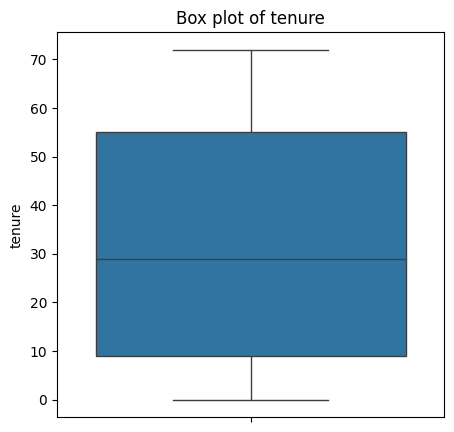

In [ ]:
plot_boxplot(df,"tenure")

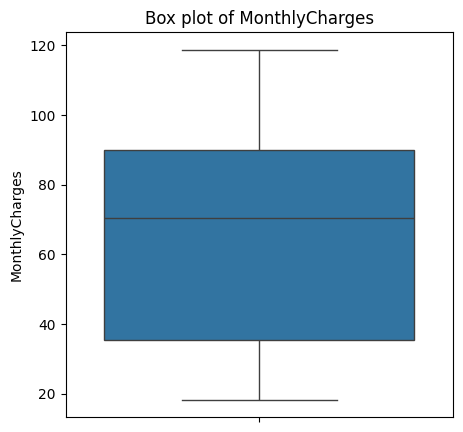

In [ ]:
plot_boxplot(df,"MonthlyCharges")

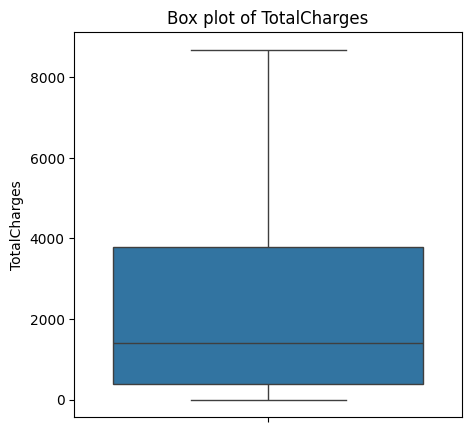

In [ ]:
plot_boxplot(df,"TotalCharges")

Heatmap

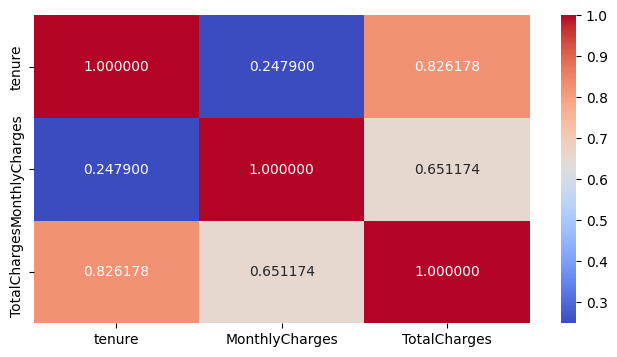

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt="2f")
plt.show()


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


count plot for categorical column


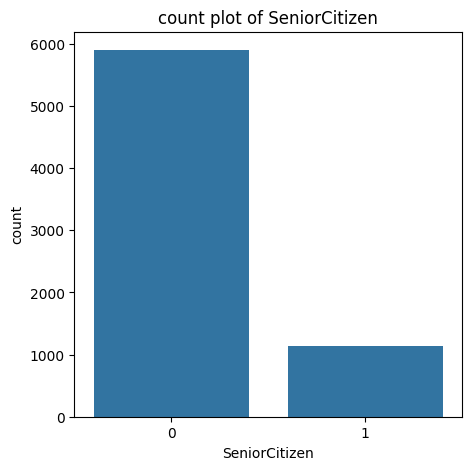

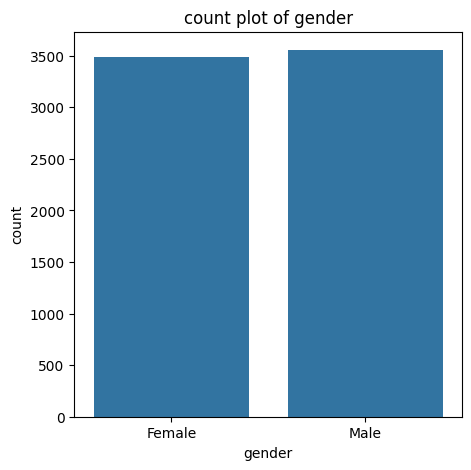

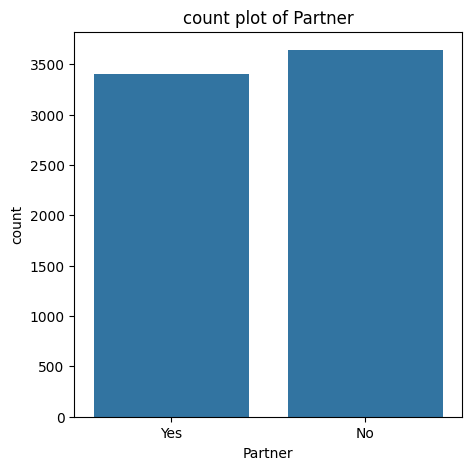

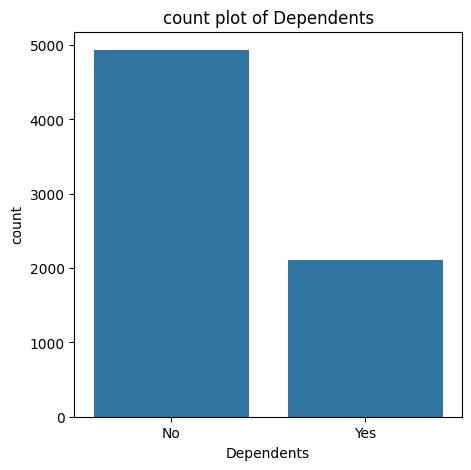

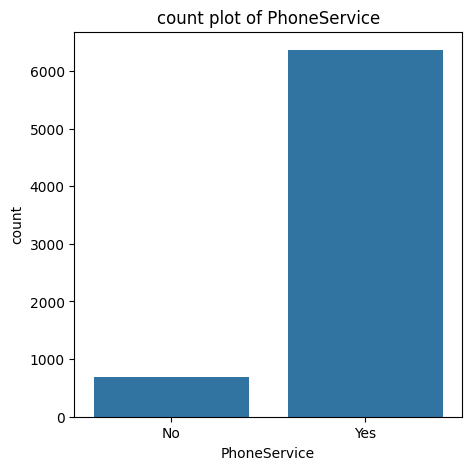

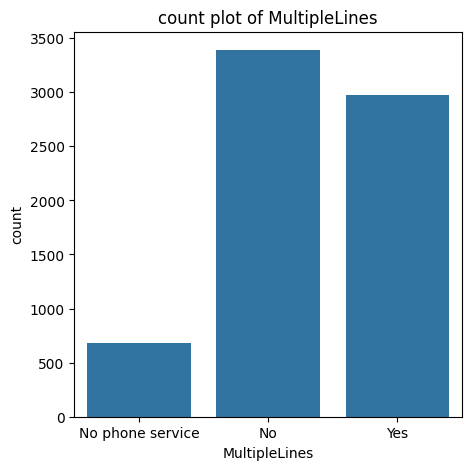

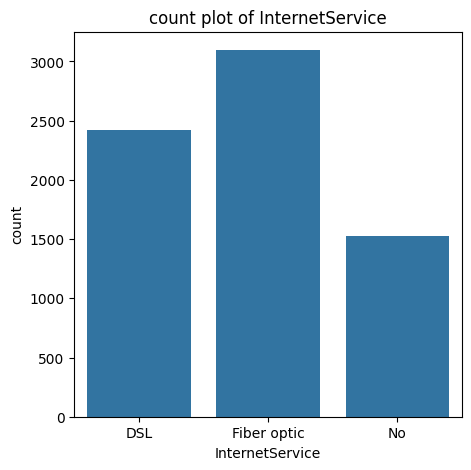

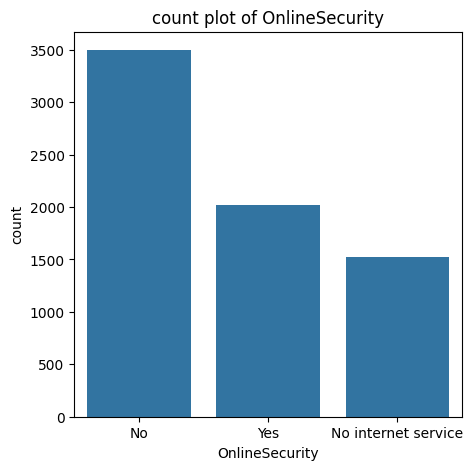

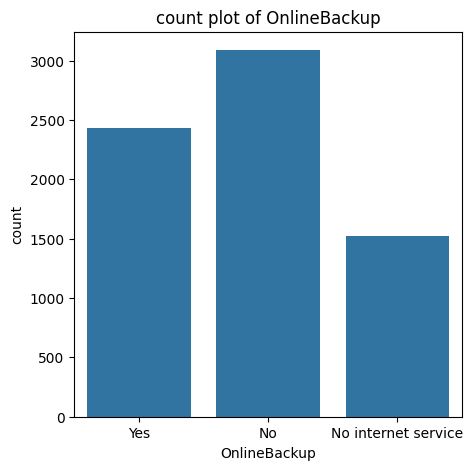

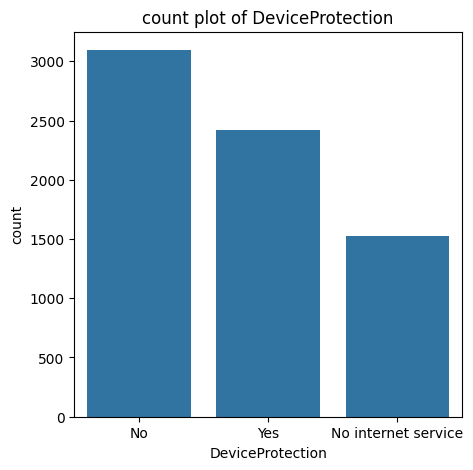

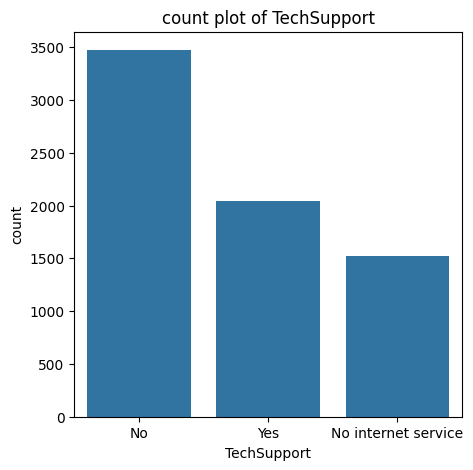

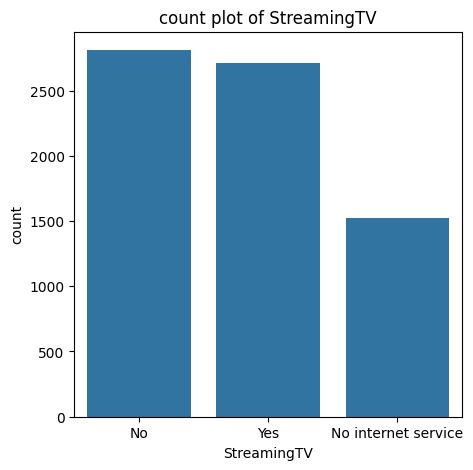

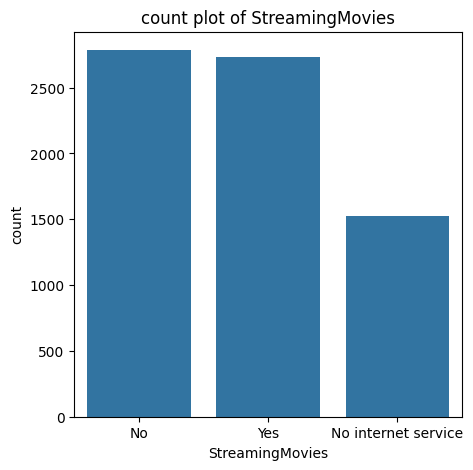

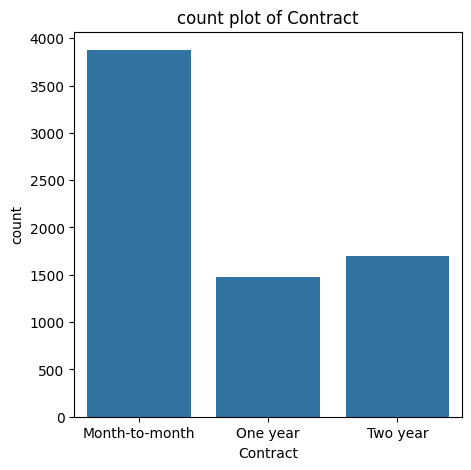

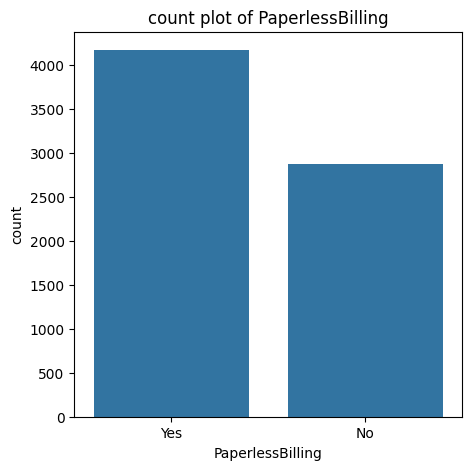

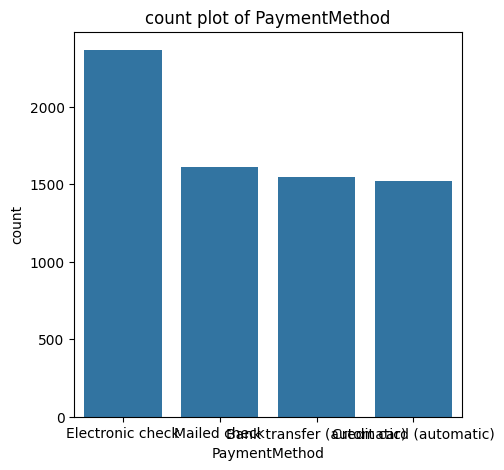

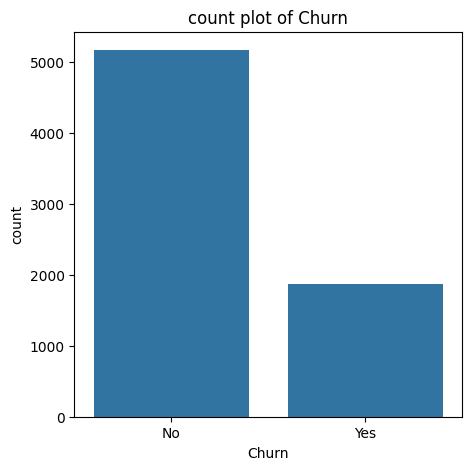

In [ ]:
obj_col=df.select_dtypes(include="object").columns.to_list()
obj_col=["SeniorCitizen"]+obj_col
obj_col

for col in obj_col:
 plt.figure(figsize=(5,5))
 sns.countplot(x=df[col])
 plt.title(f"count plot of {col}")
 plt.show()

Data processing

lable encoding

In [ ]:
df["Churn"]= df["Churn"].replace({"Yes":1,"No":0})

/tmp/ipykernel_462/1733548797.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"]= df["Churn"].replace({"Yes":1,"No":0})


In [ ]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [ ]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


lable encoding of categorical fetures

In [ ]:
obj_col = df.select_dtypes(include="object").columns

In [ ]:
print(obj_col)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


initialize a dictionary to save the encoders

In [ ]:
encoders={}
# apply encoding and store the encoders
for column in obj_col:
  lable_encoder = LabelEncoder()
  df[column]=lable_encoder.fit_transform(df[column])
  encoders[column]= lable_encoder
# save encoder to pickle file
with open("encoder.pkl","wb")as f:
  pickle.dump(encoders,f)

In [ ]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [ ]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


traning and test data split

In [ ]:
X= df.drop(columns=["Churn"])
Y= df["Churn"]

In [ ]:
print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [ ]:
print(Y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [ ]:
X_train, X_test, y_train,y_test= train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
print(y_train.shape)

(5634,)


In [ ]:
print(X_train.shape)

(5634, 19)


In [ ]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


SMOTE (done on training data)

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_train_smote,y_train_smote,= smote.fit_resample(X_train,y_train)

In [ ]:
print(y_train_smote.shape)

(8276,)


In [ ]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


Model Traning


In [ ]:
models={
  "Decision Tree":DecisionTreeClassifier(random_state=42),
  "Random Forest":RandomForestClassifier(random_state=42),
  "XGBoost":XGBClassifier(random_state=42)
}

In [ ]:
#store cross validation result
cv_scores={}
for model_name,model in models.items():
  print(f"Traning{model_name} with default parameter")
  scores =cross_val_score(model,X_train_smote,y_train_smote,cv=5,scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name}cross validation accuracy:{np.mean(scores):.2f}")
  print("-"*50)

TraningDecision Tree with default parameter
Decision Treecross validation accuracy:0.78
--------------------------------------------------
TraningRandom Forest with default parameter
Random Forestcross validation accuracy:0.84
--------------------------------------------------
TraningXGBoost with default parameter
XGBoostcross validation accuracy:0.83
--------------------------------------------------


In [ ]:
cv_scores

{'Decision Tree': array([0.68297101, 0.71299094, 0.82175227, 0.83564955, 0.83564955]),
 'Random Forest': array([0.72524155, 0.77824773, 0.90513595, 0.89425982, 0.90090634]),
 'XGBoost': array([0.70048309, 0.75649547, 0.90271903, 0.89486405, 0.90030211])}

Random forest Gives higest acurracy

In [ ]:
rfc =RandomForestClassifier(random_state=42)

In [ ]:
rfc.fit(X_train_smote,y_train_smote)

RandomForestClassifier(random_state=42)

model evaluation

In [ ]:
y_train_pred = rfc.predict(X_test)
print(f"Accuracy Score:\n{accuracy_score(y_test, y_train_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_train_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_train_pred)}")

Accuracy Score:
0.7785663591199432
Confusion Matrix:
[[878 158]
 [154 219]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



saving the file for future use

In [ ]:
model_data = {"model": rfc, "Features_names": X.columns.to_list()}

with open("Customer_churn_model.pkl","wb") as f:
  pickle.dump(model_data,f)

In [ ]:
import pickle
with open("Customer_churn_model.pkl","rb") as f:
  model_data = pickle.load(f)
  loaded_model=model_data["model"]
  Features_names = model_data["Features_names"]

In [ ]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

global_input_data = {}

def create_input_form(features, encoders):
    input_widgets = {}
    output_widget = widgets.Output()


    widget_items = []

    for feature in features:
        if feature in encoders:
            # Categorical feature: uses a dropdown for selection
            widget = widgets.Dropdown(
                options=list(encoders[feature].classes_),
                description=f'{feature}:',
                disabled=False,
            )
        elif feature == 'SeniorCitizen':
            # Binary feature (0 or 1): uses a dropdown for selection
            widget = widgets.Dropdown(
                options=[0, 1],
                description=f'{feature}:',
                disabled=False,
            )
        elif feature in ['tenure', 'MonthlyCharges', 'TotalCharges']:
            # Numerical features: uses text input fields
            if feature == 'tenure':
                widget = widgets.IntText(
                    description=f'{feature}:',
                    value=1, # Default value
                    min=0,
                )
            else: # MonthlyCharges, TotalCharges
                widget = widgets.FloatText(
                    description=f'{feature}:',
                    value=0.0, # Default value
                    min=0.0,
                )
        else:
            # Fallback for any unexpected features
            widget = widgets.Text(
                description=f'{feature}:',
                value='',
                disabled=True, # Disable if not explicitly handled
            )
        input_widgets[feature] = widget
        widget_items.append(input_widgets[feature])

    # Create a button to process the input
    predict_button = widgets.Button(description="Predict Churn", button_style='success')

    def on_button_click(b):
        with output_widget:
            output_widget.clear_output()
            global global_input_data
            new_input_data = {}
            for feature in features:
                new_input_data[feature] = input_widgets[feature].value
            global_input_data = new_input_data # Store data globally
            print("Input data updated successfully!")
            print(global_input_data)

    predict_button.on_click(on_button_click)

    # Display all widgets
    display(widgets.VBox(widget_items + [predict_button, output_widget]))

# Call the function to create and display the form
create_input_form(Features_names, encoders)

In [ ]:
input_data = global_input_data
input_data_df=pd.DataFrame([input_data])

with open("encoder.pkl","rb")as f:
  encoders=pickle.load(f)

for column, encoder in encoders.items():
  if column in input_data_df.columns:
    input_data_df[column] = encoder.transform(input_data_df[column])

if 'Churn' in input_data_df.columns:
    input_data_df = input_data_df.drop('Churn', axis=1)



In [ ]:
from IPython.display import HTML
import pandas as pd

# Ensure Features_names is available if not already in scope (though it should be from xNu7RwXXFaKh)
if 'Features_names' not in locals():
    try:
        with open("Customer_churn_model.pkl","rb") as f:
            model_data = pickle.load(f)
            Features_names = model_data["Features_names"]
    except FileNotFoundError:
        Features_names = [] # Fallback if model file is not found

# Check if input_data_df is empty or does not have the expected columns
if input_data_df.empty or not all(col in input_data_df.columns for col in Features_names):
    output_html = """
    <div style="background-color: #ffe0e0; border: 1px solid #ff9999; padding: 10px; border-radius: 5px; display: flex; align-items: center;">
        <span style="font-size: 24px; color: #cc0000; margin-right: 10px;">&#x2717;</span> <!-- Red X icon -->
        <p style="color: #cc0000; font-weight: bold; margin: 0;">Input data is missing or empty. Please fill out the form above and click 'Predict Churn' before running this cell.</p>
    </div>
    """
else:
    # Reindex input_data_df to match the feature names and order the model was trained on
    # This addresses the UserWarning about feature names and potential prediction issues.
    # Any missing columns will be added as NaN, which might require further handling if they are crucial.
    # However, given the form setup, all Features_names should be present.
    input_data_df_aligned = input_data_df.reindex(columns=Features_names, fill_value=0) # Using fill_value=0 as a default for missing numerical features if any

    prediction = loaded_model.predict(input_data_df_aligned)

    if prediction[0] == 1:
        output_html = """
        <div style="background-color: #ffe0e0; border: 1px solid #ff9999; padding: 10px; border-radius: 5px; display: flex; align-items: center;">
            <span style="font-size: 24px; color: #cc0000; margin-right: 10px;">&#x2717;</span> <!-- Red X icon -->
            <p style="color: #cc0000; font-weight: bold; margin: 0;">The customer is <span style="font-size: 1.2em;">LIKELY TO CHURN</span>.</p>
        </div>
        """
    else:
        output_html = """
        <div style="background-color: #e0ffe0; border: 1px solid #99ff99; padding: 10px; border-radius: 5px; display: flex; align-items: center;">
            <span style="font-size: 24px; color: #00cc00; margin-right: 10px;">&#x2713;</span> <!-- Green checkmark icon -->
            <p style="color: #00cc00; font-weight: bold; margin: 0;">The customer is <span style="font-size: 1.2em;">NOT likely to churn</span>.</p>
        </div>
        """
display(HTML(output_html))